# Umbilicus Detection using YOLOv26

This notebook demonstrates a complete workflow for training and evaluating an object detection model for umbilicus localization using the YOLOv26 architecture.

The notebook includes dataset verification, model training, evaluation of training metrics, and inference on validation images.

## Table of Contents

0. Setup & Environment  
1. Import Libraries  
2. Dataset Overview  
3. Dataset Verification  
4. Dataset Visualization  
5. YOLO Dataset Configuration  
6. Model Training  
7. Training Results  
8. Model Inference  


## 0. Setup & Environment

This section installs the required libraries and prepares the environment for training and running the YOLO object detection model.

In [5]:
# Install 
%pip install -U ultralytics pillow matplotlib pyyaml

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\bamta\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


#1.import libraries
import os
import glob
import yaml
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

In [6]:
#import libraries
import os
import glob
import yaml
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

## 2. Dataset Overview

The dataset contains abdominal images with bounding box annotations around the umbilicus.

Images are organized into training(70%), validation(20%), and test(10%) sets following the standard YOLO dataset structure.

## 3. Dataset Verification

Before training the model, we verify that the dataset structure is correct.  
This includes checking directory paths and ensuring that image and label files exist.

In [7]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders in current directory:")
print(os.listdir())

Current working directory:
d:\Bam\MEng\Coding\Guided system\YOLO training

Files/folders in current directory:
['captures_rgb', 'runs', 'umbilicus-detection.v2i.yolov8', 'umbilicus-detection.v2i.yolov8.zip', 'umbilicus-detection.v3i.yolov8', 'umbilicus-detection.v3i.yolov8.zip', 'umbilicus_yolo26', 'yolo26n.pt', 'YOLO8.v2i.yolov8', 'YOLO8.v2i.yolov8.zip', 'YOLO8.v3i.yolo26', 'YOLO8.v3i.yolo26.zip', 'YOLO_DL_HW.ipynb', 'YOLO_HW2.ipynb']


In [8]:
# =========================
# USER-DEFINED PATHS
# =========================

DATASET_ROOT = r"D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26"
DATA_YAML = os.path.join(DATASET_ROOT, "data.yaml")

TRAIN_IMAGES = os.path.join(DATASET_ROOT, "train", "images")
TRAIN_LABELS = os.path.join(DATASET_ROOT, "train", "labels")

VALID_IMAGES = os.path.join(DATASET_ROOT, "valid", "images")
VALID_LABELS = os.path.join(DATASET_ROOT, "valid", "labels")

TEST_IMAGES = os.path.join(DATASET_ROOT, "test", "images")
TEST_LABELS = os.path.join(DATASET_ROOT, "test", "labels")

PROJECT_DIR = r"D:\Bam\MEng\Coding\Guided system\YOLO training\umbilicus_yolo26"
RUN_NAME = "trial1"

MODEL_NAME = "yolo26n.pt"

### Path Check

The following cell checks whether all important dataset paths exist.  
If any path returns `False`, it should be corrected before proceeding.

In [9]:
paths_to_check = {
    "DATASET_ROOT": DATASET_ROOT,
    "DATA_YAML": DATA_YAML,
    "TRAIN_IMAGES": TRAIN_IMAGES,
    "TRAIN_LABELS": TRAIN_LABELS,
    "VALID_IMAGES": VALID_IMAGES,
    "VALID_LABELS": VALID_LABELS,
    "TEST_IMAGES": TEST_IMAGES,
    "TEST_LABELS": TEST_LABELS,
    "PROJECT_DIR": PROJECT_DIR,
}

for name, path in paths_to_check.items():
    print(f"{name}:")
    print(path)
    print("Exists:", os.path.exists(path))
    print("-" * 60)

DATASET_ROOT:
D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26
Exists: True
------------------------------------------------------------
DATA_YAML:
D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\data.yaml
Exists: True
------------------------------------------------------------
TRAIN_IMAGES:
D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\train\images
Exists: True
------------------------------------------------------------
TRAIN_LABELS:
D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\train\labels
Exists: True
------------------------------------------------------------
VALID_IMAGES:
D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\valid\images
Exists: True
------------------------------------------------------------
VALID_LABELS:
D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\valid\labels
Exists: True
------------------------------------------------------------
TEST_IMAGES:
D:\Bam\MEng\Codi

In [10]:
def count_files(folder, extensions=None):
    if not os.path.exists(folder):
        return 0
    if extensions is None:
        return len(os.listdir(folder))
    
    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(folder, f"*.{ext}")))
    return len(files)

image_exts = ["jpg", "jpeg", "png"]

print("Train images:", count_files(TRAIN_IMAGES, image_exts))
print("Train labels:", count_files(TRAIN_LABELS, ["txt"]))

print("Valid images:", count_files(VALID_IMAGES, image_exts))
print("Valid labels:", count_files(VALID_LABELS, ["txt"]))

print("Test images:", count_files(TEST_IMAGES, image_exts))
print("Test labels:", count_files(TEST_LABELS, ["txt"]))

Train images: 123
Train labels: 123
Valid images: 35
Valid labels: 35
Test images: 18
Test labels: 18


## 4. Dataset Visualization

Visualizing sample images helps confirm that the dataset is loaded correctly and provides an overview of the image content before training.

Number of sample training images found: 123


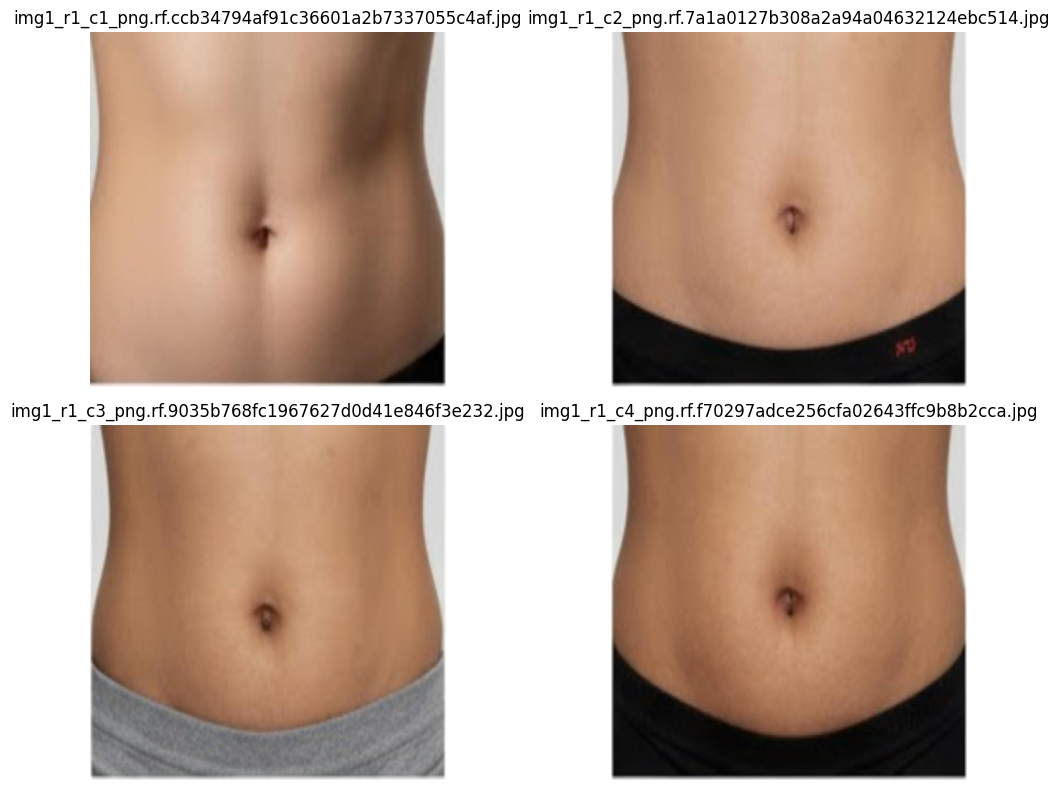

In [11]:
sample_images = (
    glob.glob(os.path.join(TRAIN_IMAGES, "*.jpg")) +
    glob.glob(os.path.join(TRAIN_IMAGES, "*.jpeg")) +
    glob.glob(os.path.join(TRAIN_IMAGES, "*.png"))
)

print("Number of sample training images found:", len(sample_images))

if len(sample_images) > 0:
    plt.figure(figsize=(12, 8))
    for i, img_path in enumerate(sample_images[:4]):
        img = Image.open(img_path)
        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No training images found.")

## 5. YOLO Dataset Configuration

The dataset configuration is defined in the `data.yaml` file.  
This file specifies the training and validation paths, as well as the object class used for detection.

In [12]:
if os.path.exists(DATA_YAML):
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        data_config = yaml.safe_load(f)
    
    print("Contents of data.yaml:")
    print(data_config)
else:
    raise FileNotFoundError(f"data.yaml not found: {DATA_YAML}")

Contents of data.yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['umbilicus'], 'roboflow': {'workspace': 'tanyaporns-workspace', 'project': 'yolo8-h7vko', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/tanyaporns-workspace/yolo8-h7vko/dataset/3'}}


In [13]:
required_keys = ["train", "val", "names"]
missing_keys = [k for k in required_keys if k not in data_config]

if len(missing_keys) == 0:
    print("data.yaml contains all required keys.")
else:
    print("Missing keys in data.yaml:", missing_keys)

if "names" in data_config:
    print("\nClass names:")
    print(data_config["names"])

data.yaml contains all required keys.

Class names:
['umbilicus']


## 6. Model Training

In this section, the **YOLOv26 object detection model** is trained using the prepared dataset.

Transfer learning is applied by starting from a pretrained YOLO model and adapting it to the umbilicus detection task.

In [14]:
# Load pretrained YOLO model
model = YOLO(MODEL_NAME)

# Train the model
results = model.train(
    data=DATA_YAML,
    epochs=20,
    imgsz=640,
    batch=4,
    project=PROJECT_DIR,
    name=RUN_NAME
)

Ultralytics 8.4.26  Python-3.9.6 torch-2.8.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=trial12, nbs=64, nms=False, opset=None, optimize=False, opti

## 7. Training Results

After training, YOLO automatically generates training curves that summarize the model’s learning progress.

These curves include loss values and evaluation metrics such as precision, recall, and mean average precision.

In [15]:
RUN_DIR = results.save_dir
RESULTS_PNG = os.path.join(RUN_DIR, "results.png")
BEST_MODEL_PATH = os.path.join(RUN_DIR, "weights", "best.pt")
LAST_MODEL_PATH = os.path.join(RUN_DIR, "weights", "last.pt")

print("Run directory:", RUN_DIR)
print("RESULTS_PNG exists:", os.path.exists(RESULTS_PNG))
print("BEST_MODEL_PATH exists:", os.path.exists(BEST_MODEL_PATH))
print("LAST_MODEL_PATH exists:", os.path.exists(LAST_MODEL_PATH))

Run directory: D:\Bam\MEng\Coding\Guided system\YOLO training\umbilicus_yolo26\trial12
RESULTS_PNG exists: True
BEST_MODEL_PATH exists: True
LAST_MODEL_PATH exists: True


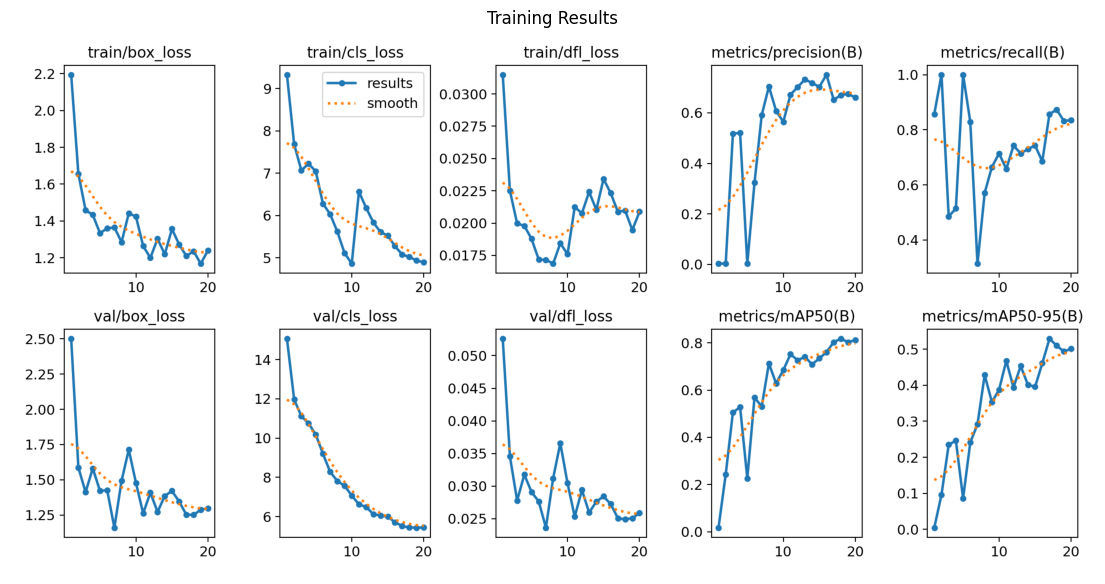

In [16]:
if os.path.exists(RESULTS_PNG):
    img = Image.open(RESULTS_PNG)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Training Results")
    plt.show()
else:
    print("results.png not found.")

## 8. Model Inference

The trained model is used to perform inference on validation images.

The output includes bounding boxes showing the predicted location of the umbilicus.

In [17]:
if os.path.exists(BEST_MODEL_PATH):
    best_model = YOLO(BEST_MODEL_PATH)
    print("Best model loaded successfully.")
else:
    raise FileNotFoundError(f"best.pt not found: {BEST_MODEL_PATH}")

Best model loaded successfully.


In [18]:
best_model.predict(
    source=VALID_IMAGES,
    conf=0.25,
    save=True,
    show=True
)


image 1/35 D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\valid\images\img1_r2_c1_png.rf.cf9768099cbae5adc141eaa6cc863119.jpg: 640x640 1 umbilicus, 111.1ms
image 2/35 D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\valid\images\img1_r2_c5_png.rf.7020352d00a7bdb9e62c9c36ba914b97.jpg: 640x640 1 umbilicus, 107.1ms
image 3/35 D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\valid\images\img1_r3_c1_png.rf.a9c076bb1776c8d1ec7c0aa7cb678ce3.jpg: 640x640 1 umbilicus, 102.3ms
image 4/35 D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\valid\images\img1_r4_c1_png.rf.234843c9dc8225fdb43ff754d8f6d2d1.jpg: 640x640 1 umbilicus, 103.4ms
image 5/35 D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\valid\images\img1_r4_c4_png.rf.c660999cdd0b3e2aea733a75511787f5.jpg: 640x640 1 umbilicus, 112.2ms
image 6/35 D:\Bam\MEng\Coding\Guided system\YOLO training\YOLO8.v3i.yolo26\valid\images\img1_r5_c3_png.rf.c9e1b2a5f5c5a437065b3b01f941

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'umbilicus'}
 obb: None
 orig_img: array([[[242, 249, 252],
         [241, 248, 251],
         [240, 247, 250],
         ...,
         [251, 253, 253],
         [252, 254, 254],
         [252, 254, 254]],
 
        [[243, 250, 253],
         [242, 249, 252],
         [241, 248, 251],
         ...,
         [249, 251, 251],
         [250, 252, 252],
         [250, 252, 252]],
 
        [[244, 249, 250],
         [243, 248, 249],
         [239, 246, 249],
         ...,
         [247, 249, 249],
         [248, 250, 250],
         [249, 251, 251]],
 
        ...,
 
        [[215, 217, 217],
         [214, 216, 216],
         [213, 215, 215],
         ...,
         [220, 220, 220],
         [231, 231, 231],
         [238, 238, 238]],
 
        [[235, 240, 239],
         [234, 239, 238],
         [233, 238, 237],
         ...,
         [238, 

Number of prediction images: 35


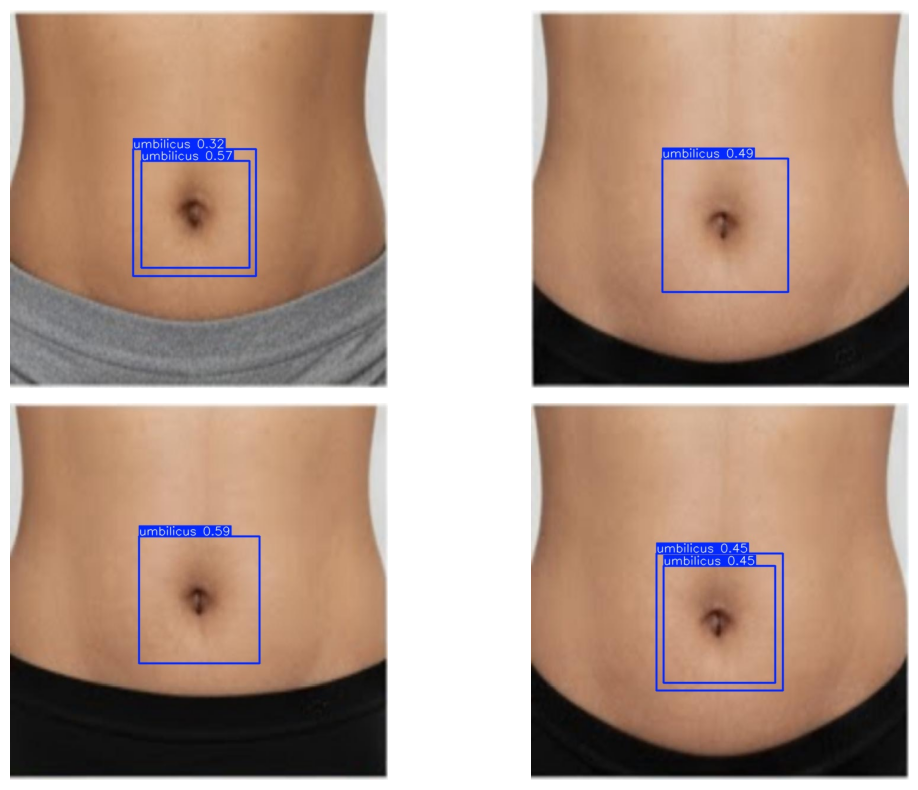

In [19]:
import glob

predict_folder = os.path.join("runs", "detect", "predict")

images = glob.glob(os.path.join(predict_folder, "*.jpg"))

print("Number of prediction images:", len(images))

plt.figure(figsize=(12,8))

for i, img_path in enumerate(images[:4]):   # show first 4 predictions
    img = Image.open(img_path)
    
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")
    
plt.tight_layout()
plt.show()